In [2]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

In [3]:
from src.Preprocessing import get_preprocessed_data
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

Creating database directory...
Data folders created.
Database file found. Initializing connection...
No new CSVs to import to the database. Returning connection...
Connection initialized.


In [4]:
X_train, X_test, y_train, y_test = get_preprocessed_data(output_as='random_split')

print(X_train.shape)
print(X_test.shape)

Retrieved 74635 rows of data from the database.
Processing 74635 rows of data.
Finished parsing PostalCode.
Finished cyclical encoding CloseDate.
Finished transforming abs(DaysOnMarket).
Finished transforming log(ClosePrice).
Found pre-trained encoder model for Flooring. Returning artifact...
Encoding Flooring...
Encoded Flooring with MultiLabelBinarizer.
Finished de-stacking and encoding Flooring.
Found pre-trained encoder model for Levels. Returning artifact...
Encoding Levels...
Encoded Levels with MultiLabelBinarizer.
Finished de-stacking and encoding Levels.
Finished feature engineering.
Found pre-trained imputer model for YearBuilt. Returning artifact...
Finished imputation for YearBuilt.
Found pre-trained imputer model for BedroomsTotal. Returning artifact...
Finished imputation for BedroomsTotal.
Found pre-trained imputer model for BathroomsTotalInteger. Returning artifact...
Finished imputation for BathroomsTotalInteger.
Finished imputing ['YearBuilt', 'BedroomsTotal', 'Bathro

In [4]:
X_train.dtypes

Latitude                        float64
Longitude                       float64
PostalCode                      float64
AttachedGarageYN                float64
BathroomsTotalInteger           float64
BedroomsTotal                   float64
FireplaceYN                     float64
GarageSpaces                    float64
LivingArea                      float64
MainLevelBedrooms               float64
NewConstructionYN               float64
ParkingTotal                    float64
PoolPrivateYN                   float64
Stories                         float64
ViewYN                          float64
YearBuilt                       float64
LotSizeAcres                    float64
LotSizeArea                     float64
LotSizeSquareFeet               float64
AssociationFee                  float64
CloseDate                datetime64[us]
DaysOnMarket                    float64
sin_closed_date                 float64
cos_closed_date                 float64
Flooring_Bamboo                 float64


In [5]:
X_train

,Latitude,Longitude,PostalCode,AttachedGarageYN,BathroomsTotalInteger,BedroomsTotal,FireplaceYN,GarageSpaces,LivingArea,MainLevelBedrooms,...,Flooring_Laminate,Flooring_SeeRemarks,Flooring_Stone,Flooring_Tile,Flooring_Vinyl,Flooring_Wood,Levels_MultiSplit,Levels_One,Levels_ThreeOrMore,Levels_Two
54824,34.090105,-118.249073,90026.0,0.0,3.0,2.0,0.0,1.0,1256.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
51576,36.597097,-121.863551,93940.0,1.0,2.0,3.0,0.0,2.0,1320.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
58279,34.480540,-117.354676,92392.0,1.0,2.0,3.0,1.0,2.0,1860.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
54912,33.223016,-117.355580,92058.0,1.0,3.0,5.0,1.0,3.0,2940.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
50837,33.969631,-117.466725,92509.0,1.0,3.0,3.0,0.0,2.0,1583.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37202,33.707484,-117.788149,92606.0,1.0,3.0,4.0,1.0,2.0,2268.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6266,34.092496,-117.412774,92335.0,1.0,2.0,3.0,1.0,2.0,1260.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
54895,32.777117,-117.189609,92110.0,1.0,2.0,3.0,0.0,2.0,1298.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,34.074362,-117.731794,91767.0,1.0,2.0,3.0,1.0,2.0,1730.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [6]:
X_train["YearBuilt"]

54824    1930.0
51576    2007.0
58279    1990.0
54912    2004.0
50837    2025.0
          ...  
37202    1974.0
6266     1956.0
54895    1958.0
860      1963.0
15802    2025.0
Name: YearBuilt, Length: 59699, dtype: float64

In [7]:
X_train["LivingArea"]

54824    1256.0
51576    1320.0
58279    1860.0
54912    2940.0
50837    1583.0
          ...  
37202    2268.0
6266     1260.0
54895    1298.0
860      1730.0
15802    2537.0
Name: LivingArea, Length: 59699, dtype: float64

In [8]:
X_train["PostalCode"]

54824    90026.0
51576    93940.0
58279    92392.0
54912    92058.0
50837    92509.0
          ...   
37202    92606.0
6266     92335.0
54895    92110.0
860      91767.0
15802    92571.0
Name: PostalCode, Length: 59699, dtype: float64

In [9]:
X_train["BedroomsTotal"]

54824    2.0
51576    3.0
58279    3.0
54912    5.0
50837    3.0
        ... 
37202    4.0
6266     3.0
54895    3.0
860      3.0
15802    5.0
Name: BedroomsTotal, Length: 59699, dtype: float64

In [10]:
X_train["BathroomsTotalInteger"]

54824    3.0
51576    2.0
58279    2.0
54912    3.0
50837    3.0
        ... 
37202    3.0
6266     2.0
54895    2.0
860      2.0
15802    3.0
Name: BathroomsTotalInteger, Length: 59699, dtype: float64

Drop CloseDate and PostalCode to train the models.

In [4]:
X_train_cp = X_train.copy()
X_test_cp = X_test.copy()

In [5]:
drop_cols = ["CloseDate", "PostalCode"]

X_train_cp = X_train_cp.drop(columns=drop_cols)
X_test_cp  = X_test_cp.drop(columns=drop_cols)

(*)Adding new feature only to train the linear model.

In [6]:
X_train_new = X_train_cp.copy()
X_test_new = X_test_cp.copy()
X_train_new["bed_bath_ratio"] = X_train_new["BedroomsTotal"] / (X_train_new["BathroomsTotalInteger"] + 1e-6)
X_test_new["bed_bath_ratio"] = X_test_new["BedroomsTotal"] / (X_test_new["BathroomsTotalInteger"] + 1e-6)

# X_train_new["property_age"] = X_train_new["CloseDate"].dt.year - X_train_new["YearBuilt"]
# X_test_new["property_age"] = X_test_new["CloseDate"].dt.year - X_test_new["YearBuilt"]

# Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

In [9]:
lm = LinearRegression()
lm.fit(X_train_cp, y_train)

y_pred = lm.predict(X_test_cp)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.3319077446696973
R2: 0.5378106106755246


(*)Try to fit the new dataset to linear model.

Using X_train_new and X_test_new:

In [10]:
lm = LinearRegression()
lm.fit(X_train_new, y_train)

y_pred = lm.predict(X_test_new)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.33190832263180103
R2: 0.5378090010223082


# Ridge Regression

In [5]:
X_train_rr = X_train.copy().drop(columns="CloseDate")
X_test_rr = X_test.copy().drop(columns="CloseDate")

In [6]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train_rr, y_train)

y_pred = ridge.predict(X_test_rr)

ridge.score(X_test_rr, y_test)

r2_ridge = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Ridge R2:", r2_ridge)
print("Ridge RMSE:", rmse)

Ridge R2: 0.5411389963758995
Ridge RMSE: 0.33071049406992337


/Users/jenny/Desktop/IDX Exchange Intership/California-House-Price-Prediction/.venv/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.088106946177624e-18.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


# Random Forest

In [14]:
X_train_rf = X_train.copy().drop(columns="CloseDate")
X_test_rf = X_test.copy().drop(columns="CloseDate")

(*)RF tuning based on n_estimators and max_depth.

In [29]:
for depth in [15, 20, 30]:
    for n in [100, 200, 300]:

        rf = RandomForestRegressor(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )

        rf.fit(X_train_rf, y_train)
        y_pred = rf.predict(X_test_rf)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        train_r2 = rf.score(X_train_rf, y_train)

        print(f"n={n}, depth={depth}")
        print("Train R2:", train_r2)
        print("Test  R2:", r2)
        print("RMSE:", rmse)
        print("---------")

n=100, depth=15
Train R2: 0.9551304927622009
Test  R2: 0.8564320320193657
RMSE: 0.18498485673159337
---------
n=200, depth=15
Train R2: 0.9552748191611622
Test  R2: 0.8601795498358732
RMSE: 0.18255458657061352
---------
n=300, depth=15
Train R2: 0.9553194127264619
Test  R2: 0.85979924529321
RMSE: 0.18280268759424204
---------
n=100, depth=20
Train R2: 0.9785004042100913
Test  R2: 0.8711079948269749
RMSE: 0.17527516749888927
---------
n=200, depth=20
Train R2: 0.978527049425082
Test  R2: 0.8730953906312995
RMSE: 0.17391862734821265
---------
n=300, depth=20
Train R2: 0.978653603962624
Test  R2: 0.8727543001550937
RMSE: 0.17415219719340472
---------
n=100, depth=30
Train R2: 0.9833630556146091
Test  R2: 0.8718255703302366
RMSE: 0.17478658518390555
---------
n=200, depth=30
Train R2: 0.9834303499392895
Test  R2: 0.8747986389274267
RMSE: 0.1727475616003697
---------
n=300, depth=30
Train R2: 0.9836646354649555
Test  R2: 0.8748336464909401
RMSE: 0.17272340893151972
---------


(*)Checking overfitting.

     n  depth    RMSE  Train_R2  Test_R2     Gap
0  100     15  0.1850    0.9551   0.8564  0.0987
1  200     15  0.1826    0.9553   0.8602  0.0951
2  300     15  0.1828    0.9553   0.8598  0.0955
3  100     20  0.1753    0.9785   0.8711  0.1074
4  200     20  0.1739    0.9785   0.8731  0.1054
5  300     20  0.1742    0.9787   0.8728  0.1059
6  100     30  0.1748    0.9834   0.8718  0.1115
7  200     30  0.1727    0.9834   0.8748  0.1086
8  300     30  0.1727    0.9837   0.8748  0.1088


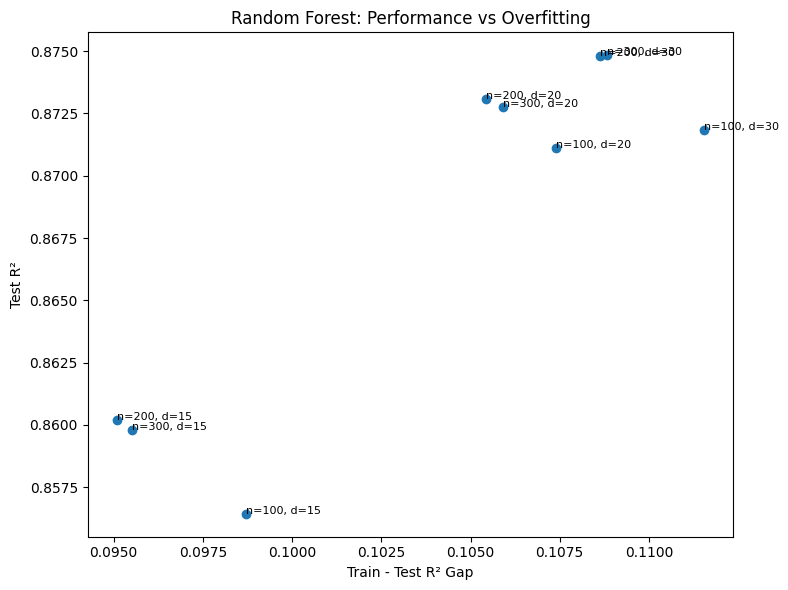

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

rows = [
    {"n": 100, "depth": 15, "RMSE": 0.18498485673159334, "Train_R2": 0.9551304927622009, "Test_R2": 0.8564320320193657},
    {"n": 200, "depth": 15, "RMSE": 0.18255458657061352, "Train_R2": 0.9552748191611622, "Test_R2": 0.8601795498358731},
    {"n": 300, "depth": 15, "RMSE": 0.18280268759424204, "Train_R2": 0.9553194127264619, "Test_R2": 0.85979924529321},
    {"n": 100, "depth": 20, "RMSE": 0.17527516749888927, "Train_R2": 0.9785004042100913, "Test_R2": 0.8711079948269749},
    {"n": 200, "depth": 20, "RMSE": 0.17391862734821267, "Train_R2": 0.978527049425082, "Test_R2": 0.8730953906312995},
    {"n": 300, "depth": 20, "RMSE": 0.1741521971934047, "Train_R2": 0.978653603962624, "Test_R2": 0.8727543001550937},
    {"n": 100, "depth": 30, "RMSE": 0.17478658518390552, "Train_R2": 0.9833630556146091, "Test_R2": 0.8718255703302367},
    {"n": 200, "depth": 30, "RMSE": 0.1727475616003697, "Train_R2": 0.9834303499392895, "Test_R2": 0.8747986389274267},
    {"n": 300, "depth": 30, "RMSE": 0.17272340893151966, "Train_R2": 0.9836646354649555, "Test_R2": 0.8748336464909401},
]

df = pd.DataFrame(rows)

# Create the overfitting gap
df["Gap"] = df["Train_R2"] - df["Test_R2"]

# Print table
print(df.round(4))

# Scatter plot: overfitting vs performance
plt.figure(figsize=(8, 6))
plt.scatter(df["Gap"], df["Test_R2"])

for _, row in df.iterrows():
    plt.annotate(
        f"n={int(row['n'])}, d={int(row['depth'])}",
        (row["Gap"], row["Test_R2"]),
        fontsize=8
    )

plt.xlabel("Train - Test R² Gap")
plt.ylabel("Test R²")
plt.title("Random Forest: Performance vs Overfitting")
plt.tight_layout()
plt.show()

After tuning n_estimators and max_depth, the best Random Forest uses 300 trees and depth 30. $R^2$ = 0.8748. However, considering the overfitting, 200 trees and depth 20 could be a better one with $R^2$ = 0.873.

# XGBoost

In [23]:
X_train_xgb = X_train.copy().drop(columns="CloseDate")
X_test_xgb = X_test.copy().drop(columns="CloseDate")

In [24]:
import xgboost as xgb

Baseline mdoel:

In [25]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train)
y_pred = xgb_model.predict(X_test_xgb)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 0.17728224382062274
R2: 0.868139208545286


(*)XGBoost tuning based on n_estimators, max_depth, and learning_rate.

In [27]:
for depth in [3, 4, 6, 8]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [200, 300, 500]:
            model = xgb.XGBRegressor(
                n_estimators=n,
                max_depth=depth,
                learning_rate=lr,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train_xgb, y_train)
            y_pred = model.predict(X_test_xgb)
            y_train_pred = model.predict(X_train_xgb)

            rmse = np.sqrt(mean_squared_error(y_test, y_pred))
            r2 = r2_score(y_test, y_pred)
            train_r2 = r2_score(y_train, y_train_pred)

            gap = train_r2 - r2

            print(f"n={n}, depth={depth}, lr={lr}")
            print("Train R2:", train_r2)
            print("Test  R2:", r2)
            print("RMSE:", rmse)
            print("Gap:", gap)
            print("---------")

n=200, depth=3, lr=0.03
Train R2: 0.7817411410681857
Test  R2: 0.7493477763314803
RMSE: 0.24442362553008845
Gap: 0.0323933647367054
---------
n=300, depth=3, lr=0.03
Train R2: 0.8098235897177445
Test  R2: 0.7748801696612087
RMSE: 0.23164038451333904
Gap: 0.034943420056535834
---------
n=500, depth=3, lr=0.03
Train R2: 0.8329531134276316
Test  R2: 0.7999524105965726
RMSE: 0.21836049091198187
Gap: 0.03300070283105894
---------
n=200, depth=3, lr=0.05
Train R2: 0.8157950848650447
Test  R2: 0.7819382849663976
RMSE: 0.22798019064929576
Gap: 0.033856799898647094
---------
n=300, depth=3, lr=0.05
Train R2: 0.8333136086713453
Test  R2: 0.8013073100483141
RMSE: 0.2176197692553586
Gap: 0.03200629862303117
---------
n=500, depth=3, lr=0.05
Train R2: 0.8545466836508856
Test  R2: 0.8251697594760268
RMSE: 0.20413415636519516
Gap: 0.02937692417485882
---------
n=200, depth=3, lr=0.1
Train R2: 0.8471390924566563
Test  R2: 0.8168429171817924
RMSE: 0.20893887870567782
Gap: 0.030296175274863946
---------

(*)Checking overfitting

      n  depth    lr  Train_R2  Test_R2     Gap
0   200      3  0.03    0.7817   0.7493  0.0324
1   300      3  0.03    0.8098   0.7749  0.0349
2   500      3  0.03    0.8330   0.8000  0.0330
3   200      3  0.05    0.8158   0.7819  0.0339
4   300      3  0.05    0.8333   0.8013  0.0320
5   500      3  0.05    0.8545   0.8252  0.0293
6   200      3  0.10    0.8471   0.8168  0.0303
7   300      3  0.10    0.8615   0.8329  0.0286
8   500      3  0.10    0.8785   0.8520  0.0265
9   200      4  0.05    0.8465   0.8132  0.0333
10  300      4  0.05    0.8629   0.8312  0.0317
11  500      4  0.05    0.8831   0.8533  0.0298
12  200      6  0.05    0.8937   0.8546  0.0391
13  300      6  0.05    0.9107   0.8681  0.0426
14  500      6  0.05    0.9300   0.8810  0.0490
15  200      8  0.05    0.9376   0.8794  0.0582
16  300      8  0.05    0.9512   0.8867  0.0645
17  500      8  0.05    0.9658   0.8926  0.0732


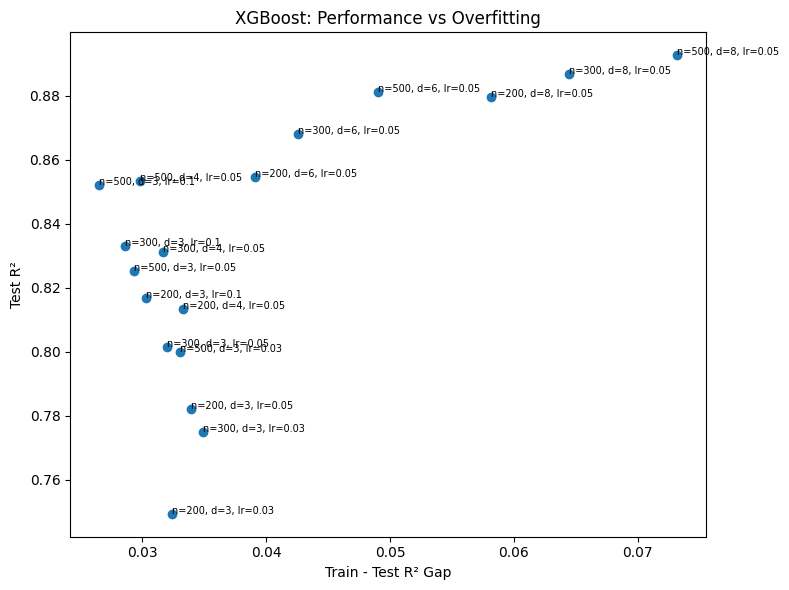

In [30]:
rows = [
{"n":200,"depth":3,"lr":0.03,"Train_R2":0.7817,"Test_R2":0.7493},
{"n":300,"depth":3,"lr":0.03,"Train_R2":0.8098,"Test_R2":0.7749},
{"n":500,"depth":3,"lr":0.03,"Train_R2":0.8330,"Test_R2":0.8000},

{"n":200,"depth":3,"lr":0.05,"Train_R2":0.8158,"Test_R2":0.7819},
{"n":300,"depth":3,"lr":0.05,"Train_R2":0.8333,"Test_R2":0.8013},
{"n":500,"depth":3,"lr":0.05,"Train_R2":0.8545,"Test_R2":0.8252},

{"n":200,"depth":3,"lr":0.1,"Train_R2":0.8471,"Test_R2":0.8168},
{"n":300,"depth":3,"lr":0.1,"Train_R2":0.8615,"Test_R2":0.8329},
{"n":500,"depth":3,"lr":0.1,"Train_R2":0.8785,"Test_R2":0.8520},

{"n":200,"depth":4,"lr":0.05,"Train_R2":0.8465,"Test_R2":0.8132},
{"n":300,"depth":4,"lr":0.05,"Train_R2":0.8629,"Test_R2":0.8312},
{"n":500,"depth":4,"lr":0.05,"Train_R2":0.8831,"Test_R2":0.8533},

{"n":200,"depth":6,"lr":0.05,"Train_R2":0.8937,"Test_R2":0.8546},
{"n":300,"depth":6,"lr":0.05,"Train_R2":0.9107,"Test_R2":0.8681},
{"n":500,"depth":6,"lr":0.05,"Train_R2":0.9300,"Test_R2":0.8810},

{"n":200,"depth":8,"lr":0.05,"Train_R2":0.9376,"Test_R2":0.8794},
{"n":300,"depth":8,"lr":0.05,"Train_R2":0.9512,"Test_R2":0.8867},
{"n":500,"depth":8,"lr":0.05,"Train_R2":0.9658,"Test_R2":0.8926},
]

df = pd.DataFrame(rows)

# gap
df["Gap"] = df["Train_R2"] - df["Test_R2"]

print(df.round(4))

plt.figure(figsize=(8,6))
plt.scatter(df["Gap"], df["Test_R2"])

for _, row in df.iterrows():
    plt.annotate(
        f"n={int(row['n'])}, d={int(row['depth'])}, lr={row['lr']}",
        (row["Gap"], row["Test_R2"]),
        fontsize=7
    )

plt.xlabel("Train - Test R² Gap")
plt.ylabel("Test R²")
plt.title("XGBoost: Performance vs Overfitting")

plt.tight_layout()
plt.show()

The gap is actually lower than what rf does. After tuning, XGBoost outperforms Random Forest. The best model could be depth=8, 500 trees, and learning rate 0.05 with $R^2$ = 0.89.

# SHAP Analysis

In [31]:
import shap
import matplotlib.pyplot as plt

/Users/jenny/Desktop/IDX Exchange Intership/California-House-Price-Prediction/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
import xgboost as xgb

best_xgb = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train_xgb, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [34]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, The experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:CloseDate: datetime64[us]

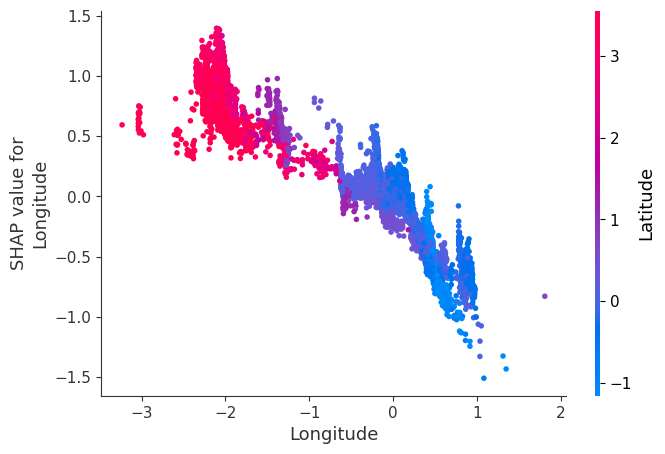

In [16]:
shap.dependence_plot("Longitude", shap_values, X_test)

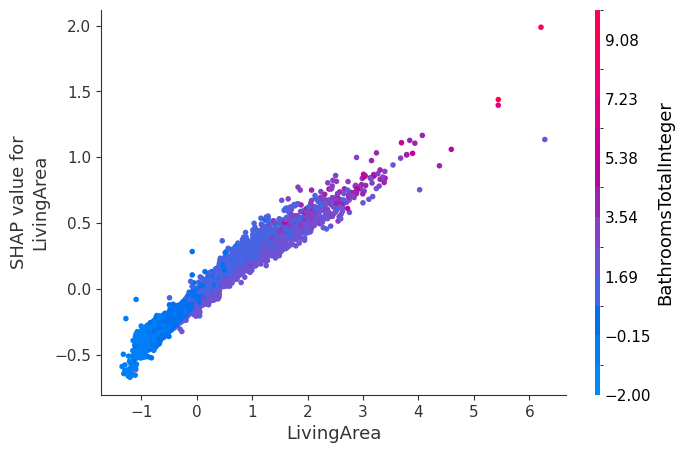

In [17]:
shap.dependence_plot("LivingArea", shap_values, X_test)